In [1]:
# The Supervised Machine Learning Process (Classification algorithms)
##########################################  Step 1 Data Wrangling & prerocessing #####################
# Step 1 Part 0 Installing machine learning libraries and data wrangling libraries = Done
# Step 1 Part 1 Importing libraries = Done
# Step 1 part 2 Importing dataset = Done (imported into and sql database and then export into csv)
# Step 1 part 3 Taking care of missing data and duplicates = Done (no missing data or duplicates)
# Step 1 part 4 Encoding categorical data = Done, no need for missing but the dataset is checked!
# Step 1 part 5 Feature selection (creating a matrix of features, and the dependant variable we are predicting = Done, machine learning process expects these two entities)
# Step 1 part 6 Splitting dataset into training and test
# Step 1 part 7 Feature scaling

######################################### Step 3 Random Forests #############################

# Step 3 Part 0 
# Step 3 Part 1 
# Step 3 part 2 
######################################### THE END #############################


################# Resources and Datasets ########################

###########https://data.mendeley.com/datasets/6tm2d6sz7p/1 ###### Dataset.csv #### Published: 7 June 2023 (0=legitimate,1=phishing)
#1. df_Dataset = pd.read_csv('datasets/Dataset.csv')

#2. df_phishing_csv = pd.read_csv('datasets/phishing_dataset.csv', on_bad_lines='skip')# https://gregavrbancic.github.io/Phishing-Dataset/# 2020 dataset

################# Machine learning resoruces 
# https://www.youtube.com/watch?v=i_LwzRVP7bg&t=2687s


In [2]:
# Step 1 Part 0 Installing machine learning libraries and data wrangling libraries = Done

import sys
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install scikit-learn
!{sys.executable}pip install xgboost
!{sys.executable} pip install CMake

zsh:1: no such file or directory: /opt/homebrew/anaconda3/bin/pythonpip
/opt/homebrew/anaconda3/bin/python: can't open file '/Users/perceval/data_science/machine_learning/msc_project/pip': [Errno 2] No such file or directory


In [3]:
# Step 1 Part 1 Importing libraries = Done

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import joblib
from joblib import dump

In [4]:
# Step 1 part 2 Importing dataset, creating a matrix of features, and the dependant variable we are predicting = Done, machine learning process expects these two entities
#df_phishing_csv = pd.read_csv('datasets/phishing_dataset.csv', on_bad_lines='skip')# https://gregavrbancic.github.io/Phishing-Dataset/# 2020 dataset

df_phishing_csv = pd.read_csv('datasets/Dataset.csv', on_bad_lines='skip') # https://data.mendeley.com/datasets/6tm2d6sz7p/1 #2023 dataset with 0=legitimate, 1 = phishing


In [5]:
has_nan = df_phishing_csv.isnull().values.any()
has_nan

False

In [6]:
cleaned_df = df_phishing_csv.dropna(how='any')
cleaned_df

,Type,url_length,number_of_dots_in_url,having_repeated_digits_in_url,number_of_digits_in_url,number_of_special_char_in_url,number_of_hyphens_in_url,number_of_underline_in_url,number_of_slash_in_url,number_of_questionmark_in_url,...,having_digits_in_subdomain,number_of_digits_in_subdomain,having_repeated_digits_in_subdomain,having_path,path_length,having_query,having_fragment,having_anchor,entropy_of_url,entropy_of_domain
0,0,37,2,0,0,8,0,0,5,0,...,0,0,1,0,3,0,0,0,4.010412,2.751629
1,1,70,5,0,0,12,0,0,6,0,...,0,0,1,0,4,0,0,0,4.089470,3.532573
2,0,42,2,0,6,8,0,0,3,1,...,0,0,1,0,1,1,0,0,4.386016,3.344698
3,0,46,2,0,0,7,0,0,4,0,...,0,0,1,0,2,0,0,0,4.221947,3.189898
4,0,51,3,0,0,9,0,0,5,0,...,0,0,1,0,3,0,0,0,4.103538,2.952820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247945,0,42,1,0,0,6,0,0,4,0,...,0,0,1,0,2,0,0,0,3.758289,3.323231
247946,0,42,2,0,0,8,0,0,5,0,...,0,0,1,0,3,0,0,0,3.937093,3.026987
247947,1,33,2,0,0,8,0,0,5,0,...,0,0,1,0,3,0,0,0,3.813207,3.327820
247948,1,83,1,1,19,9,0,0,7,0,...,0,0,1,0,5,0,0,0,4.540173,3.375000


In [7]:
# Step 1 part 2 preview dataset
cleaned_df

,Type,url_length,number_of_dots_in_url,having_repeated_digits_in_url,number_of_digits_in_url,number_of_special_char_in_url,number_of_hyphens_in_url,number_of_underline_in_url,number_of_slash_in_url,number_of_questionmark_in_url,...,having_digits_in_subdomain,number_of_digits_in_subdomain,having_repeated_digits_in_subdomain,having_path,path_length,having_query,having_fragment,having_anchor,entropy_of_url,entropy_of_domain
0,0,37,2,0,0,8,0,0,5,0,...,0,0,1,0,3,0,0,0,4.010412,2.751629
1,1,70,5,0,0,12,0,0,6,0,...,0,0,1,0,4,0,0,0,4.089470,3.532573
2,0,42,2,0,6,8,0,0,3,1,...,0,0,1,0,1,1,0,0,4.386016,3.344698
3,0,46,2,0,0,7,0,0,4,0,...,0,0,1,0,2,0,0,0,4.221947,3.189898
4,0,51,3,0,0,9,0,0,5,0,...,0,0,1,0,3,0,0,0,4.103538,2.952820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247945,0,42,1,0,0,6,0,0,4,0,...,0,0,1,0,2,0,0,0,3.758289,3.323231
247946,0,42,2,0,0,8,0,0,5,0,...,0,0,1,0,3,0,0,0,3.937093,3.026987
247947,1,33,2,0,0,8,0,0,5,0,...,0,0,1,0,3,0,0,0,3.813207,3.327820
247948,1,83,1,1,19,9,0,0,7,0,...,0,0,1,0,5,0,0,0,4.540173,3.375000


In [8]:
# Step 1 part 2 #describe dataset
cleaned_df.describe()

,Type,url_length,number_of_dots_in_url,having_repeated_digits_in_url,number_of_digits_in_url,number_of_special_char_in_url,number_of_hyphens_in_url,number_of_underline_in_url,number_of_slash_in_url,number_of_questionmark_in_url,...,having_digits_in_subdomain,number_of_digits_in_subdomain,having_repeated_digits_in_subdomain,having_path,path_length,having_query,having_fragment,having_anchor,entropy_of_url,entropy_of_domain
count,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,...,247950.000000,247950.000000,247950.0,247950.0,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000,247950.000000
mean,0.481585,58.358197,2.894075,0.162351,4.366070,10.303218,0.600867,0.204049,4.784533,0.159911,...,0.064529,0.224013,1.0,0.0,2.606977,0.126501,0.002303,0.000944,4.257222,3.389839
std,0.499662,29.764620,1.690970,0.368773,9.579032,4.718381,1.235599,0.653502,1.812574,0.449506,...,0.245694,1.276447,0.0,0.0,1.636938,0.332414,0.047933,0.030706,0.328098,0.376361
min,0.000000,12.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,2.000000,0.000000,...,0.000000,0.000000,1.0,0.0,0.000000,0.000000,0.000000,0.000000,2.648939,1.386274
25%,0.000000,39.000000,2.000000,0.000000,0.000000,7.000000,0.000000,0.000000,4.000000,0.000000,...,0.000000,0.000000,1.0,0.0,2.000000,0.000000,0.000000,0.000000,4.038910,3.180833
50%,0.000000,49.000000,3.000000,0.000000,0.000000,9.000000,0.000000,0.000000,4.000000,0.000000,...,0.000000,0.000000,1.0,0.0,2.000000,0.000000,0.000000,0.000000,4.208298,3.392747
75%,1.000000,69.000000,3.000000,0.000000,4.000000,11.000000,1.000000,0.000000,5.000000,0.000000,...,0.000000,0.000000,1.0,0.0,3.000000,0.000000,0.000000,0.000000,4.428036,3.606937
max,1.000000,191.000000,28.000000,1.000000,144.000000,75.000000,23.000000,47.000000,30.000000,17.000000,...,1.000000,44.000000,1.0,0.0,28.000000,1.000000,1.000000,1.000000,5.866327,4.957323


In [9]:
# Step 1 part 2 #number of records and features (247950 records with 42 features)
cleaned_df.shape

(247950, 42)

In [10]:
# Step 1 part 2 #information about columns and data types
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247950 entries, 0 to 247949
Data columns (total 42 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Type                                       247950 non-null  int64  
 1   url_length                                 247950 non-null  int64  
 2   number_of_dots_in_url                      247950 non-null  int64  
 3   having_repeated_digits_in_url              247950 non-null  int64  
 4   number_of_digits_in_url                    247950 non-null  int64  
 5   number_of_special_char_in_url              247950 non-null  int64  
 6   number_of_hyphens_in_url                   247950 non-null  int64  
 7   number_of_underline_in_url                 247950 non-null  int64  
 8   number_of_slash_in_url                     247950 non-null  int64  
 9   number_of_questionmark_in_url              247950 non-null  int64  
 10  number_o

In [11]:
# Step 1 part 3 Taking care of missing data
# Check for missing values
print(cleaned_df.isnull().sum())

Type                                         0
url_length                                   0
number_of_dots_in_url                        0
having_repeated_digits_in_url                0
number_of_digits_in_url                      0
number_of_special_char_in_url                0
number_of_hyphens_in_url                     0
number_of_underline_in_url                   0
number_of_slash_in_url                       0
number_of_questionmark_in_url                0
number_of_equal_in_url                       0
number_of_at_in_url                          0
number_of_dollar_in_url                      0
number_of_exclamation_in_url                 0
number_of_hashtag_in_url                     0
number_of_percent_in_url                     0
domain_length                                0
number_of_dots_in_domain                     0
number_of_hyphens_in_domain                  0
having_special_characters_in_domain          0
number_of_special_characters_in_domain       0
having_digits

In [12]:
# Step 1 part 3a Taking care of missing data
print(cleaned_df.isnull().sum())


Type                                         0
url_length                                   0
number_of_dots_in_url                        0
having_repeated_digits_in_url                0
number_of_digits_in_url                      0
number_of_special_char_in_url                0
number_of_hyphens_in_url                     0
number_of_underline_in_url                   0
number_of_slash_in_url                       0
number_of_questionmark_in_url                0
number_of_equal_in_url                       0
number_of_at_in_url                          0
number_of_dollar_in_url                      0
number_of_exclamation_in_url                 0
number_of_hashtag_in_url                     0
number_of_percent_in_url                     0
domain_length                                0
number_of_dots_in_domain                     0
number_of_hyphens_in_domain                  0
having_special_characters_in_domain          0
number_of_special_characters_in_domain       0
having_digits

In [13]:
# Step 1 part 3b Taking care of missing data
#checking for unique records on each column
print(cleaned_df['Type'].nunique())

2


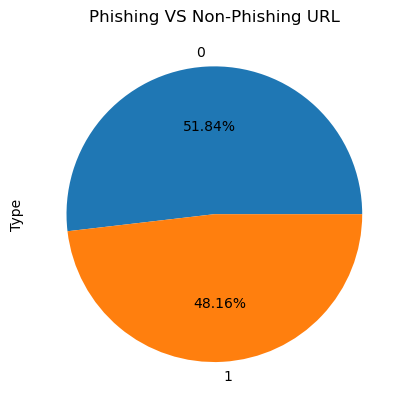

In [14]:
#Step 1 part 3c Distribution of phishing links to non phishing links
# Count in a pie chart
cleaned_df['Type'].value_counts().plot(kind='pie', autopct='%1.2f%%')
plt.title("Phishing VS Non-Phishing URL")
plt.show()

# print(cleaned_df['Type'].nunique())

In [15]:
# Step 1 part 3d #distribution of categorical data in column result,

print(cleaned_df['Type'].value_counts())

0    128541
1    119409
Name: Type, dtype: int64


In [16]:
# Step 1 part 3e Taking care of missing data
print(cleaned_df.isnull().sum())


Type                                         0
url_length                                   0
number_of_dots_in_url                        0
having_repeated_digits_in_url                0
number_of_digits_in_url                      0
number_of_special_char_in_url                0
number_of_hyphens_in_url                     0
number_of_underline_in_url                   0
number_of_slash_in_url                       0
number_of_questionmark_in_url                0
number_of_equal_in_url                       0
number_of_at_in_url                          0
number_of_dollar_in_url                      0
number_of_exclamation_in_url                 0
number_of_hashtag_in_url                     0
number_of_percent_in_url                     0
domain_length                                0
number_of_dots_in_domain                     0
number_of_hyphens_in_domain                  0
having_special_characters_in_domain          0
number_of_special_characters_in_domain       0
having_digits

In [17]:
# Step 1 part 3f Taking care of missing data
#checking for unique records on each column
print(cleaned_df['Type'].nunique())

2


In [18]:
# Step 1 part 4 #distribution of categorical data in column result,


In [19]:
# Step 1 part 4 Encoding categorical data 
#distribution of categorical data in column Type
#Column Type has already 1 & 0 therefore there is no need to encode the data into categorical values
print(cleaned_df['Type'].value_counts())

0    128541
1    119409
Name: Type, dtype: int64


In [20]:
# Step 1 part 5 Feature selection (creating a matrix of features from the dataset)

X = cleaned_df.iloc[:, 1:].values #get all valriable (features) except the first column
y = cleaned_df.iloc[:, 0].values #get all pridictive values from the first column

In [21]:

print(X)

[[37.          2.          0.         ...  0.          4.01041207
   2.75162917]
 [70.          5.          0.         ...  0.          4.08946998
   3.53257326]
 [42.          2.          0.         ...  0.          4.38601593
   3.34469838]
 ...
 [33.          2.          0.         ...  0.          3.81320653
   3.32781953]
 [83.          1.          1.         ...  0.          4.54017264
   3.375     ]
 [34.          3.          0.         ...  0.          4.0352735
   3.18200582]]


In [22]:
print(y)

[0 1 0 ... 1 1 0]


In [23]:
# Step 1 part 6 (Option 1) Splitting dataset into training and test

# valid dataset i.e used to ensure that the model can  handle unseen data after training
# training dataset i.e used to train the model
# test dataset i.e use to evaluate the model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)



In [24]:
# Step 1 part 7 feature scaling to improve training perfomance
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [25]:
# Import the model we are using
#Fitting Decision Tree classifier to the training set  
from sklearn.ensemble import RandomForestClassifier  
classifier= RandomForestClassifier(n_estimators= 10, criterion="entropy")  
classifier.fit(X_train, y_train)  

RandomForestClassifier(criterion='entropy', n_estimators=10)

In [26]:
#Predicting the Test set result
y_pred = classifier.predict(X_test)  


In [27]:
y_pred

array([1, 0, 0, ..., 0, 1, 1])

In [28]:
#Creating the Confusion matrix  
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)



In [29]:
cm

array([[25080,   667],
       [ 1243, 22600]])

In [30]:
# from the above matrix
# incorect predictions => 1261 + 661 = 1 922
# Correct predictions => 25086 + 22582 = 47 668
# True Positive 22582
# True Negative 25086


In [31]:
# import the metrics class
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score,matthews_corrcoef,r2_score

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     25747
           1       0.97      0.95      0.96     23843

    accuracy                           0.96     49590
   macro avg       0.96      0.96      0.96     49590
weighted avg       0.96      0.96      0.96     49590



In [32]:
print("Accuracy")
print(accuracy_score(y_test, y_pred))



Accuracy
0.961484170195604


In [33]:
print("Precision Score")
print(precision_score(y_test, y_pred))

Precision Score
0.9713327889285254


In [34]:
print("Recall score")
print(recall_score(y_test, y_pred))

Recall score
0.9478672985781991


In [35]:
print("F1-score")
print(f1_score(y_test, y_pred))

F1-score
0.9594565909573338


In [36]:
print("ROC Score")
print(roc_auc_score(y_test, y_pred))

ROC Score
0.9609806838950731


In [37]:
print("MCC")
print(matthews_corrcoef(y_test, y_pred))

MCC
0.9230359214441343


In [38]:

########################################## important features #####################
feature_importances = classifier.feature_importances_

In [39]:
feature_importance_pairs = zip(cleaned_df.columns, feature_importances)

In [40]:
sorted_features = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)



In [41]:
# Prin


In [42]:
labels, values = zip(*sorted_features)

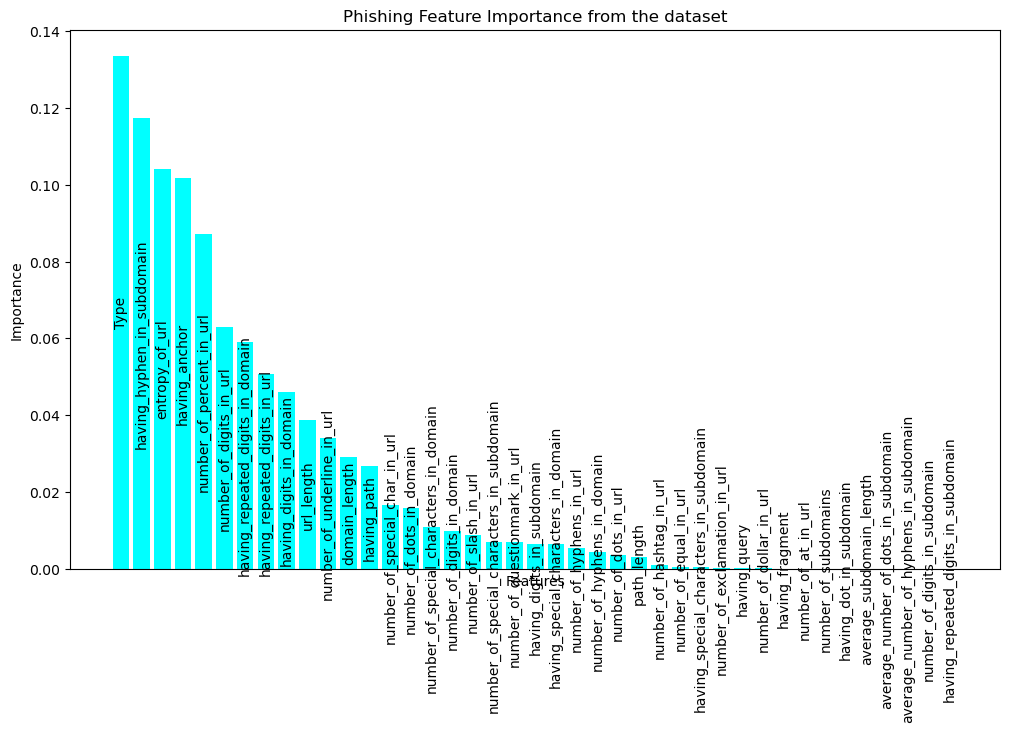

In [43]:
plt.figure(figsize=(12, 7))
bars = plt.bar(labels, values, color='cyan')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Phishing Feature Importance from the dataset')

# Displaying feature titles vertically 
for bar, label in zip(bars, labels):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval/2, label, ha='center', va='center', color='black', rotation=90)

# Removing the labels at the bottom 
plt.xticks([])

plt.show()

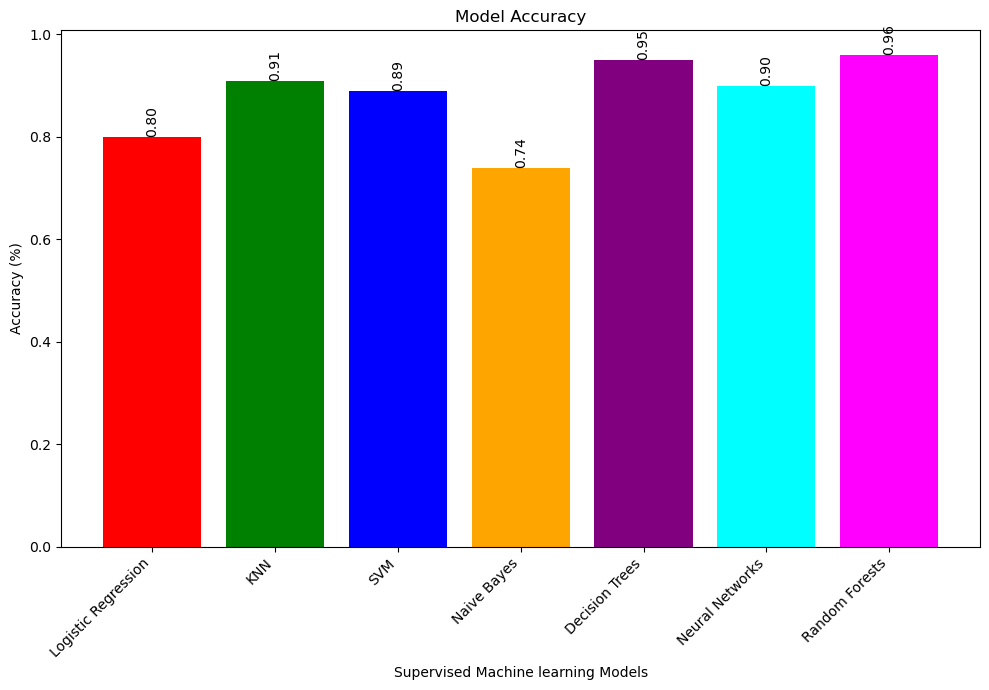

In [44]:

# Defining the accuracy data 
accuracy_data = {
    'Models': ['Logistic Regression','KNN','SVM','Naive Bayes','Decision Trees', 'Neural Networks', 'Random Forests'],
    'Accuracy': [0.80, 0.91, 0.89, 0.74, 0.95, 0.90, 0.96]
}

# Creating the DataFrame again
accuracy_df = pd.DataFrame(accuracy_data)

# Plotting a bar graph with different colors. Extending the color list to match the number of categories.
colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta']
plt.figure(figsize=(10, 7))
bars = plt.bar(accuracy_df['Models'], accuracy_df['Accuracy'], color=colors)

# Adding accuracy scores to the top of the bars 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', verticalalignment='bottom', ha='center', rotation=90)

plt.title('Model Accuracy')
plt.xlabel('Supervised Machine learning Models')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')  # Rotate model names for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()



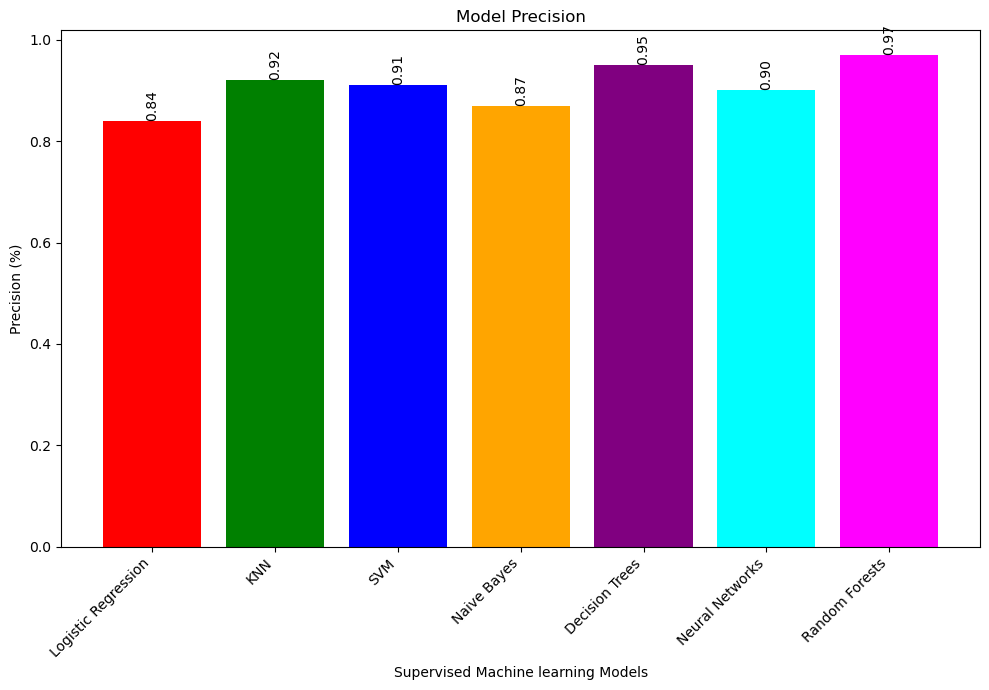

In [45]:
# Ranking by precision

# Defining the accuracy data 
precision_data = {
    'Models': ['Logistic Regression','KNN','SVM','Naive Bayes','Decision Trees', 'Neural Networks', 'Random Forests'],
    'Precision': [0.84, 0.92, 0.91, 0.87, 0.95, 0.90, 0.97]
}

# Creating the DataFrame again
precision_df = pd.DataFrame(precision_data)

# Plotting a bar graph with different colors. Extending the color list to match the number of categories.
colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta']
plt.figure(figsize=(10, 7))
bars = plt.bar(precision_df['Models'], precision_df['Precision'], color=colors)

# Adding accuracy scores to the top of the bars 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', verticalalignment='bottom', ha='center', rotation=90)

plt.title('Model Precision')
plt.xlabel('Supervised Machine learning Models')
plt.ylabel('Precision (%)')
plt.xticks(rotation=45, ha='right')  # Rotate model names for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

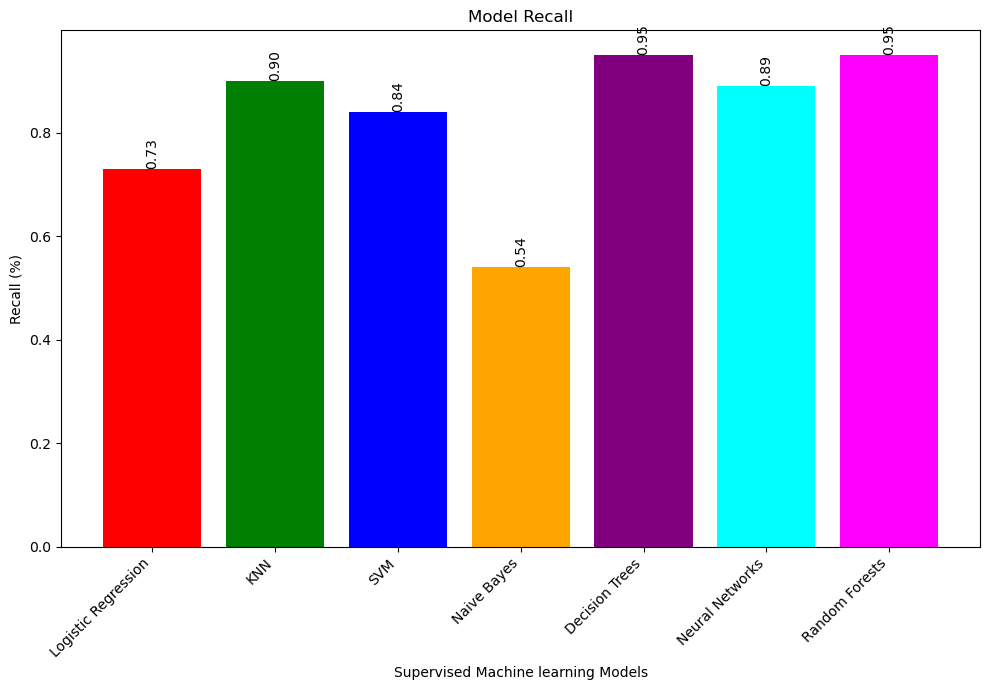

In [46]:
# Ranking by recall

recall_data = {
    'Models': ['Logistic Regression','KNN','SVM','Naive Bayes','Decision Trees', 'Neural Networks', 'Random Forests'],
    'Recall': [0.73, 0.90, 0.84, 0.54, 0.95, 0.89, 0.95]
}

# Creating the DataFrame again
recall_df = pd.DataFrame(recall_data)

# Plotting a bar graph with different colors. Extending the color list to match the number of categories.
colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta']
plt.figure(figsize=(10, 7))
bars = plt.bar(recall_df['Models'], recall_df['Recall'], color=colors)

# Adding accuracy scores to the top of the bars 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', verticalalignment='bottom', ha='center', rotation=90)

plt.title('Model Recall')
plt.xlabel('Supervised Machine learning Models')
plt.ylabel('Recall (%)')
plt.xticks(rotation=45, ha='right')  # Rotate model names for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

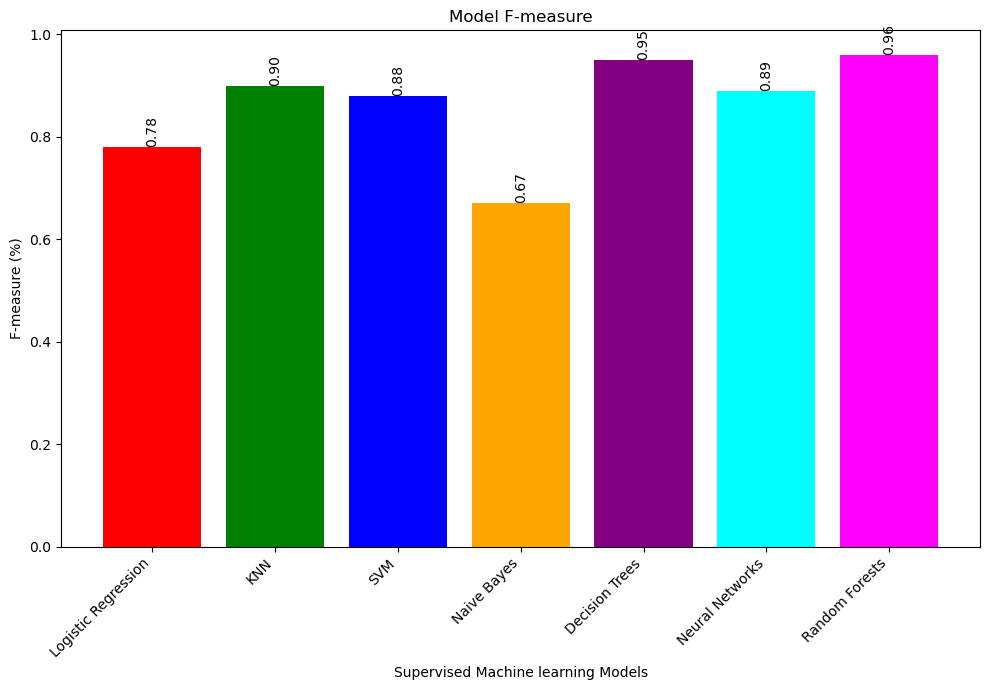

In [47]:
# Ranking by F-measure


# Defining the fmeasure
fmeasure_data = {
    'Models': ['Logistic Regression','KNN','SVM','Naive Bayes','Decision Trees', 'Neural Networks', 'Random Forests'],
    'F-measure': [0.78, 0.90, 0.88, 0.67, 0.95, 0.89, 0.96]
}

# Creating the DataFrame again
fmeasure_df = pd.DataFrame(fmeasure_data)

# Plotting a bar graph with different colors. Extending the color list to match the number of categories.
colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta']
plt.figure(figsize=(10, 7))
bars = plt.bar(fmeasure_df['Models'], fmeasure_df['F-measure'], color=colors)

# Adding accuracy scores to the top of the bars 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', verticalalignment='bottom', ha='center', rotation=90)

plt.title('Model F-measure')
plt.xlabel('Supervised Machine learning Models')
plt.ylabel('F-measure (%)')
plt.xticks(rotation=45, ha='right')  # Rotate model names for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

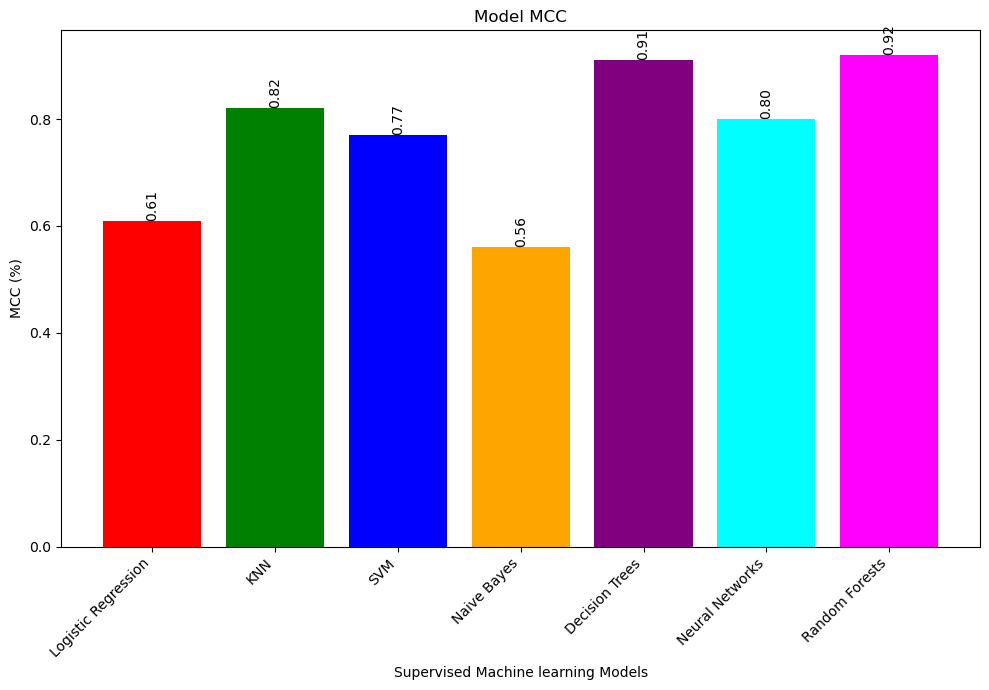

In [48]:
# Ranking by Mathews Correlation Coefficient

# Defining the MCC data
mcc_data = {
    'Models': ['Logistic Regression','KNN','SVM','Naive Bayes','Decision Trees', 'Neural Networks', 'Random Forests'],
    'MCC': [0.61, 0.82, 0.77, 0.56, 0.91, 0.80, 0.92]
}

# Creating the DataFrame again
mcc_df = pd.DataFrame(mcc_data)

# Plotting a bar graph with different colors. Extending the color list to match the number of categories.
colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta']
plt.figure(figsize=(10, 7))
bars = plt.bar(mcc_df['Models'], mcc_df['MCC'], color=colors)

# Adding accuracy scores to the top of the bars 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', verticalalignment='bottom', ha='center', rotation=90)

plt.title('Model MCC')
plt.xlabel('Supervised Machine learning Models')
plt.ylabel('MCC (%)')
plt.xticks(rotation=45, ha='right')  # Rotate model names for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

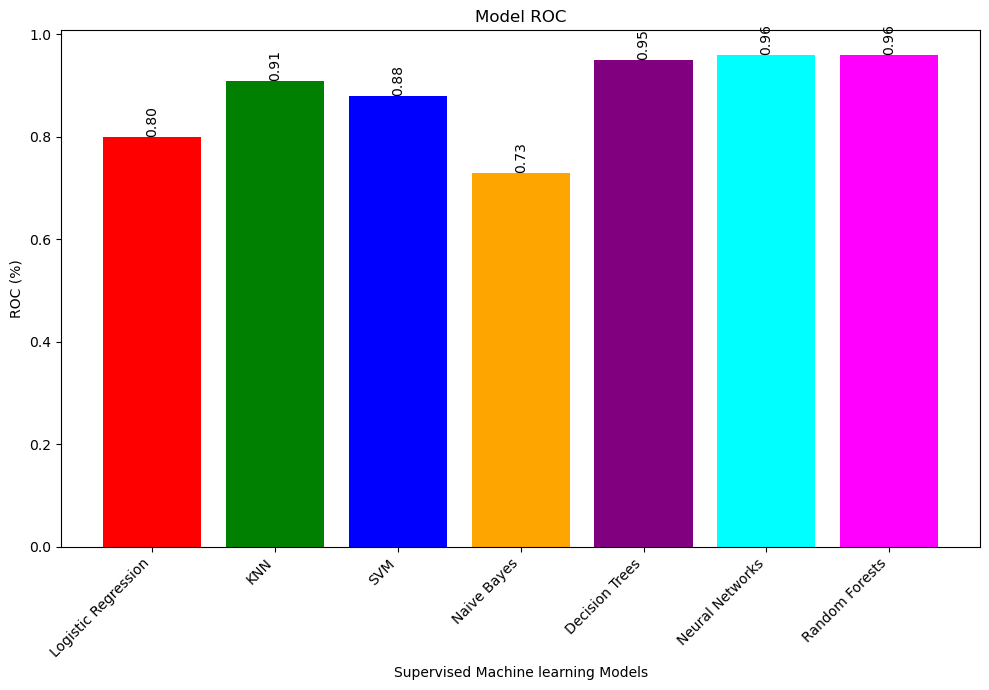

In [49]:
# Ranking by Receiver Operating Characteristic (ROC) Area

# Ranking by ROC

# Defining the MCC data
roc_data = {
    'Models': ['Logistic Regression','KNN','SVM','Naive Bayes','Decision Trees', 'Neural Networks', 'Random Forests'],
    'ROC': [0.80, 0.91, 0.88, 0.73, 0.95, 0.96, 0.96]
}

# Creating the ROC DataFrame 
roc_df = pd.DataFrame(roc_data)

# Plotting a bar graph with different colors. 
colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta']
plt.figure(figsize=(10, 7))
bars = plt.bar(roc_df['Models'], roc_df['ROC'], color=colors)

# Adding accuracy scores to the top of the bars 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', verticalalignment='bottom', ha='center', rotation=90)

plt.title('Model ROC')
plt.xlabel('Supervised Machine learning Models')
plt.ylabel('ROC (%)')
plt.xticks(rotation=45, ha='right')  # Rotate model names for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

In [50]:
joblib.dump(classifier, '/Users/perceval/data_science/machine_learning/msc_project/phishing_detect/phishing_random_forest_model.pkl')

['/Users/perceval/data_science/machine_learning/msc_project/phishing_detect/phishing_random_forest_model.pkl']

In [51]:
dump(classifier, '/Users/perceval/data_science/machine_learning/msc_project/phishing_detect/phishing_detector.joblib')

['/Users/perceval/data_science/machine_learning/msc_project/phishing_detect/phishing_detector.joblib']

In [52]:
#building the model again with a few features for the application
cleaned_df

,Type,url_length,number_of_dots_in_url,having_repeated_digits_in_url,number_of_digits_in_url,number_of_special_char_in_url,number_of_hyphens_in_url,number_of_underline_in_url,number_of_slash_in_url,number_of_questionmark_in_url,...,having_digits_in_subdomain,number_of_digits_in_subdomain,having_repeated_digits_in_subdomain,having_path,path_length,having_query,having_fragment,having_anchor,entropy_of_url,entropy_of_domain
0,0,37,2,0,0,8,0,0,5,0,...,0,0,1,0,3,0,0,0,4.010412,2.751629
1,1,70,5,0,0,12,0,0,6,0,...,0,0,1,0,4,0,0,0,4.089470,3.532573
2,0,42,2,0,6,8,0,0,3,1,...,0,0,1,0,1,1,0,0,4.386016,3.344698
3,0,46,2,0,0,7,0,0,4,0,...,0,0,1,0,2,0,0,0,4.221947,3.189898
4,0,51,3,0,0,9,0,0,5,0,...,0,0,1,0,3,0,0,0,4.103538,2.952820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247945,0,42,1,0,0,6,0,0,4,0,...,0,0,1,0,2,0,0,0,3.758289,3.323231
247946,0,42,2,0,0,8,0,0,5,0,...,0,0,1,0,3,0,0,0,3.937093,3.026987
247947,1,33,2,0,0,8,0,0,5,0,...,0,0,1,0,3,0,0,0,3.813207,3.327820
247948,1,83,1,1,19,9,0,0,7,0,...,0,0,1,0,5,0,0,0,4.540173,3.375000


In [53]:
df_django = cleaned_df[['Type','having_anchor','entropy_of_url','having_hyphen_in_subdomain','number_of_percent_in_url','having_repeated_digits_in_domain','number_of_digits_in_url','having_repeated_digits_in_url','domain_length','having_digits_in_domain','url_length','number_of_underline_in_url','having_path','number_of_dots_in_domain']]

In [54]:
df_django

,Type,having_anchor,entropy_of_url,having_hyphen_in_subdomain,number_of_percent_in_url,having_repeated_digits_in_domain,number_of_digits_in_url,having_repeated_digits_in_url,domain_length,having_digits_in_domain,url_length,number_of_underline_in_url,having_path,number_of_dots_in_domain
0,0,0,4.010412,0,0,0,0,0,12,0,37,0,0,2
1,1,0,4.089470,0,0,0,0,0,26,0,70,0,0,5
2,0,0,4.386016,0,0,0,6,0,21,1,42,0,0,2
3,0,0,4.221947,0,0,0,0,0,15,0,46,0,0,2
4,0,0,4.103538,0,0,0,0,0,16,0,51,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247945,0,0,3.758289,0,0,0,0,0,15,0,42,0,0,1
247946,0,0,3.937093,0,0,0,0,0,13,0,42,0,0,2
247947,1,0,3.813207,0,0,0,0,0,16,0,33,0,0,2
247948,1,0,4.540173,0,0,0,19,1,16,1,83,0,0,1


In [55]:
# Step 1 again feature selection

XX = df_django.iloc[:, 1:].values #get all valriable (features) except the first column
yy = df_django.iloc[:, 0].values #get all pridictive values from the first column

In [56]:
#split dataset


In [57]:
# Step 2 split dataset for the second model

from sklearn.model_selection import train_test_split
XX_train, XX_test, yy_train, yy_test = train_test_split(XX, yy, test_size = 0.2, random_state = 0)



In [58]:
# Step 3 standard scaller
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
XX_train = sc.fit_transform(XX_train)
XX_test = sc.transform(XX_test)

In [59]:
print(XX_test)

[[-0.03176925  1.6723372   0.         ... -0.31178178  0.
   0.65847362]
 [-0.03176925 -0.14361757  0.         ... -0.31178178  0.
  -0.52960895]
 [-0.03176925  0.01123972  0.         ... -0.31178178  0.
  -0.52960895]
 ...
 [-0.03176925 -0.50964065  0.         ... -0.31178178  0.
  -0.52960895]
 [-0.03176925  1.1550665   0.         ... -0.31178178  0.
   0.06443234]
 [-0.03176925  0.11879561  0.         ... -0.31178178  0.
  -0.52960895]]


In [60]:
print(XX_train)

[[-0.03176925 -1.01029264  0.         ... -0.31178178  0.
   0.06443234]
 [-0.03176925 -0.22664633  0.         ... -0.31178178  0.
  -0.52960895]
 [-0.03176925  0.16695165  0.         ... -0.31178178  0.
   0.65847362]
 ...
 [-0.03176925 -1.04452362  0.         ... -0.31178178  0.
   0.65847362]
 [-0.03176925 -0.54574376  0.         ... -0.31178178  0.
   0.06443234]
 [-0.03176925  1.23229164  0.         ... -0.31178178  0.
  -0.52960895]]


In [61]:
# Step 4 load model
#Fitting Decision Tree classifier to the training set  
from sklearn.ensemble import RandomForestClassifier  
classifier2= RandomForestClassifier(n_estimators= 10, criterion="entropy")  
classifier2.fit(XX_train, yy_train)  

RandomForestClassifier(criterion='entropy', n_estimators=10)

In [62]:
# Step 5 second prediction
y_pred2 = classifier2.predict(XX_test)  


In [63]:
# import the metrics class
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score,matthews_corrcoef,r2_score

print(classification_report(yy_test, y_pred2))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92     25747
           1       0.92      0.89      0.91     23843

    accuracy                           0.91     49590
   macro avg       0.91      0.91      0.91     49590
weighted avg       0.91      0.91      0.91     49590



In [64]:
joblib.dump(classifier2, '/Users/perceval/data_science/machine_learning/msc_project/phishing_detect/phishing_random_forest_model_2.pkl')

['/Users/perceval/data_science/machine_learning/msc_project/phishing_detect/phishing_random_forest_model_2.pkl']

In [65]:
dump(classifier2, '/Users/perceval/data_science/machine_learning/msc_project/phishing_detect/phishing_detector_2.joblib')

['/Users/perceval/data_science/machine_learning/msc_project/phishing_detect/phishing_detector_2.joblib']